In [1]:
import os, json
import torch
import torch.nn as nn
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt
from tqdm import tqdm


In [2]:
device = "cuda" if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [3]:
train_file = "../train"
validation_file ='../validacion' 
file_json = "dataset.json"
file_binary_json ="dataset_binary.json"

In [4]:
def load_labels(dir,file):
    js_path = os.path.join(dir, file)
    with open(js_path,"r") as f:
        d = json.load(f)
    return d["labels"]


In [5]:
train_ = transforms.Compose([
    transforms.Resize((252,252)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406),
                         (0.229, 0.224, 0.225))
    ])

val_ = transforms.Compose([
    transforms.Resize((252, 252)),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406),
                         (0.229, 0.224, 0.225)),
])

In [6]:
class Dataset(Dataset):
    def __init__(self, image_dir, labels, labels_bin, transform=None, ignore_value=-1):
        self.image_dir = image_dir
        self.transform = transform
        self.labels = labels
        self.labels_bin = dict(labels_bin)
        self.ignore_value = ignore_value
    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        fname, y_class = self.labels[idx]
        img_path = os.path.join(self.image_dir, fname)
        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        y_bin = self.labels_bin.get(fname, self.ignore_value)
        return (
            img,
            torch.tensor(y_bin, dtype=torch.float32),
            torch.tensor(y_class, dtype=torch.long),
        )

In [7]:
train_labels = load_labels(train_file, file_json)
train_labels_bin = load_labels(train_file,file_binary_json)
val_labels   = load_labels(validation_file,file_json)
val_labels_bin = load_labels(validation_file,file_binary_json)

train = Dataset(train_file, train_labels, train_labels_bin, transform=train_)
val   = Dataset(validation_file,val_labels, val_labels_bin, transform=val_)

(len(train), len(val))

(12466, 2628)

In [8]:
batch_size = 32

In [9]:
dataloader = {
    "train": DataLoader(train,batch_size=batch_size,shuffle=True),
    "val" : DataLoader(val,batch_size=batch_size,shuffle=True)
}

Batch de imágenes: torch.Size([32, 3, 252, 252])
Batch de etiquetas binarias: torch.Size([32])
Batch de etiquetas multiclase: torch.Size([32])


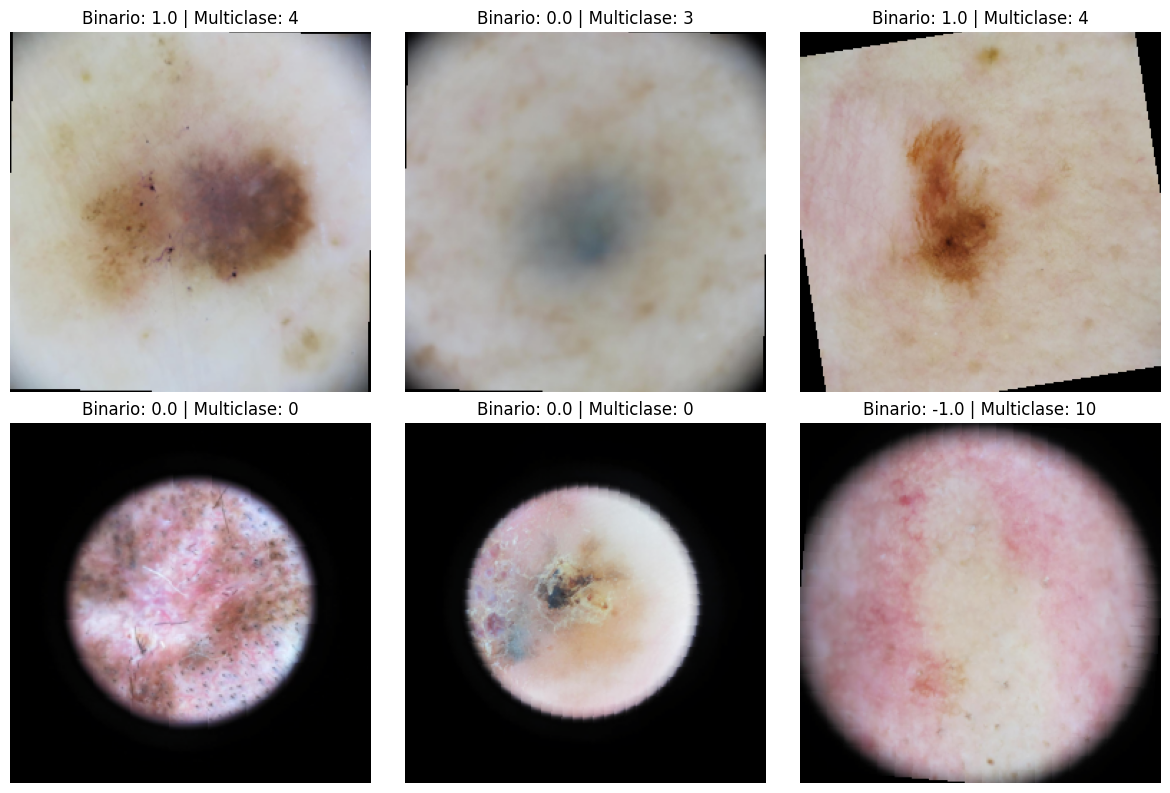

In [10]:
X, y_bin, y_class = next(iter(dataloader["train"]))

print(f"Batch de imágenes: {X.shape}")
print(f"Batch de etiquetas binarias: {y_bin.shape}")
print(f"Batch de etiquetas multiclase: {y_class.shape}")
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for i, ax in enumerate(axes.flat):
    img = X[i].permute(1, 2, 0).numpy()
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1)    
    ax.imshow(img)
    ax.set_title(f"Binario: {y_bin[i].item()} | Multiclase: {y_class[i].item()}")
    ax.axis('off')

plt.tight_layout()
plt.show()

In [11]:
X, y_bin, y_class = next(iter(dataloader["train"]))
X.shape, y_bin.shape, y_class.shape, torch.unique(y_bin), (y_class.min().item(), y_class.max().item())

(torch.Size([32, 3, 252, 252]),
 torch.Size([32]),
 torch.Size([32]),
 tensor([0., 1.]),
 (0, 5))

In [12]:
class Model(nn.Module):
    def __init__(self,n_binary=1,n_outputs=11, freeze=False):
        super().__init__()
        self.dino = torch.hub.load('facebookresearch/dinov2', 'dinov2_vitb14_reg')
        if freeze:
            for param in self.dino.parameters():
                param.requires_grad=False
        self.bh = nn.Sequential(
            nn.Linear(768,256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256,n_binary)
        )
        self.fh = torch.nn.Sequential(
            nn.Linear(768,256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256,n_outputs)
        )
    def forward(self, x):
        features = self.dino(x)
        bh = self.bh(features)
        fh = self.fh(features)
        return bh, fh

    
    def unfreeze(self):
        for param in self.dino.parameters():
            param.requires_grad=True


  
    
        

In [13]:
def fit(model, dataloader, epochs=5, lr= 0.001,w_bin=0.5, w_class=0.5):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion_bin = torch.nn.BCEWithLogitsLoss(reduction='none')
    criterion_class = torch.nn.CrossEntropyLoss()
    for epoch in range(1,epochs+1):
        model.train()
        train_loss_bin,train_loss_class, train_acc_bin, train_acc_class = [], [], [],[]
        bar = tqdm(dataloader['train'])
        for batch in bar:
            X, y_bin, y_class = batch
            X, y_bin, y_class = X.to(device), y_bin.to(device), y_class.to(device)
            optimizer.zero_grad()
            y_bin_hat, y_class_hat = model(X)
            valid_mask = (y_bin != -1)
            loss_bin = criterion_bin(y_bin_hat.squeeze(1), y_bin)
            loss_bin = loss_bin[valid_mask].mean() if valid_mask.sum() > 0 else torch.tensor(0.0).to(device)
            loss_class = criterion_class(y_class_hat, y_class)
            loss = (w_bin*loss_bin)+(w_class*loss_class)
            loss.backward()
            optimizer.step()
            train_loss_bin.append(loss_bin.item())
            train_loss_class.append(loss_class.item())
            if valid_mask.sum()>0:
                acc_bin = ((y_bin[valid_mask] == (y_bin_hat.squeeze(1)[valid_mask] > 0)).sum().item() / valid_mask.sum().item())
            else:
                acc_bin = 0.0
            acc_class = (y_class == torch.argmax(y_class_hat, axis=1)).sum().item()/len(y_class)
            train_acc_bin.append(acc_bin)
            train_acc_class.append(acc_class)
            bar.set_description(f"binary: loss {np.mean(train_loss_bin):.5f} acc{np.mean(train_acc_bin):.5f}, class: loss {np.mean(train_loss_class):.5f} acc{np.mean(train_acc_class):.5f}")
        bar = tqdm(dataloader['val'])
        val_loss_bin, val_loss_class, val_acc_bin, val_acc_class = [], [], [], []
        model.eval()
        with torch.no_grad():
            for batch in bar:
                X, y_bin, y_class = batch
                X, y_bin, y_class = X.to(device), y_bin.to(device), y_class.to(device)
                y_bin_hat, y_class_hat = model(X)
                valid_mask = (y_bin != -1)
                loss_bin = criterion_bin(y_bin_hat.squeeze(1), y_bin)
                loss_bin = loss_bin[valid_mask].mean() if valid_mask.sum() > 0 else torch.tensor(0.0).to(device)
                loss_class = criterion_class(y_class_hat, y_class)
                val_loss_bin.append(loss_bin.item())
                val_loss_class.append(loss_class.item())
                if valid_mask.sum()>0:
                    acc_bin = ((y_bin[valid_mask] == (y_bin_hat.squeeze(1)[valid_mask] > 0)).sum().item() / valid_mask.sum().item())
                else:
                    acc_bin = 0.0
                acc_class = (y_class == torch.argmax(y_class_hat, axis=1)).sum().item()/len(y_class)
                val_acc_bin.append(acc_bin)
                val_acc_class.append(acc_class)
                bar.set_description(f"binary: loss {np.mean(val_loss_bin):.5f} acc{np.mean(val_acc_bin):.5f}, class: loss {np.mean(val_loss_class):.5f} acc{np.mean(val_acc_class):.5f}")
        print(f"Epoch {epoch}/{epochs} binary: loss {np.mean(train_loss_bin):.5f}val_loss {np.mean(val_loss_bin):.5f} acc {np.mean(train_acc_bin):.5f} val_acc {np.mean(val_acc_bin):.5f}, class: loss {np.mean(train_loss_class):.5f}val_loss {np.mean(val_loss_class):.5f} acc {np.mean(train_acc_class):.5f} val_acc {np.mean(val_acc_class):.5f}")

In [14]:
model = Model(n_binary=1, n_outputs=11, freeze=True)

Using cache found in C:\Users\benig/.cache\torch\hub\facebookresearch_dinov2_main
C:\Users\benig/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
C:\Users\benig/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
C:\Users\benig/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


In [15]:
fit(model, dataloader, epochs=1, lr=0.001, w_bin=0.5, w_class=0.5)
ruta_guardado = 'pesos_dinov2_cabezas.pth'
torch.save(model.state_dict(), ruta_guardado)
print(f"¡Entrenamiento finalizado y pesos guardados en: {ruta_guardado}!")


binary: loss 0.54955 acc0.71899, class: loss 1.36198 acc0.54561: 100%|██████████| 390/390 [09:31<00:00,  1.47s/it]
binary: loss 0.52035 acc0.74523, class: loss 1.20070 acc0.57078: 100%|██████████| 83/83 [01:55<00:00,  1.40s/it]


Epoch 1/1 binary: loss 0.54955val_loss 0.52035 acc 0.71899 val_acc 0.74523, class: loss 1.36198val_loss 1.20070 acc 0.54561 val_acc 0.57078
¡Entrenamiento finalizado y pesos guardados en: pesos_dinov2_cabezas.pth!


In [16]:
"""def test(model, dataloader):
    model.to(device)
    criterion_bin = torch.nn.BCEWithLogitsLoss()
    criterion_class = torch.nn.CrossEntropyLoss()
    bar = tqdm(dataloader['test'])
    test_loss_bin, test_loss_class, test_acc_bin, test_acc_class = [], [], [], []
    model.eval()
    with torch.no_grad():
        for X, y_bin, y_class in bar:
            X, y_bin, y_class = X.to(device), y_bin.to(device), y_class.to(device)
            y_bin_hat, y_class_hat = model(X)
            loss_bin = criterion_bin(y_bin_hat.squeeze(1), y_bin.float())
            loss_class = criterion_class(y_class_hat, y_class)
            test_loss_bin.append(loss_bin.item())
            test_loss_class.append(loss_class.item())
            acc_bin = (y_bin.view(-1).long() == (torch.sigmoid(y_bin_hat.view(-1))>0.5).long()).sum().item()/len(y_bin)
            acc_class = (y_class == torch.argmax(y_class_hat, axis=1)).sum().item()/len(y_class)
            test_acc_bin.append(acc_bin)
            test_acc_class.append(acc_class)
            bar.set_description(f"binary: loss {np.mean(test_loss_bin):.5f} acc{np.mean(test_acc_bin):.5f}, class: loss {np.mean(test_loss_class):.5f} acc{np.mean(test_acc_class):.5f}")
        print(f"Test binary: test_loss {np.mean(test_loss_bin):.5f} test_acc {np.mean(test_acc_bin):.5f}, class: test_loss {np.mean(test_loss_class):.5f}  test_acc {np.mean(test_acc_class):.5f}")"""

'def test(model, dataloader):\n    model.to(device)\n    criterion_bin = torch.nn.BCEWithLogitsLoss()\n    criterion_class = torch.nn.CrossEntropyLoss()\n    bar = tqdm(dataloader[\'test\'])\n    test_loss_bin, test_loss_class, test_acc_bin, test_acc_class = [], [], [], []\n    model.eval()\n    with torch.no_grad():\n        for X, y_bin, y_class in bar:\n            X, y_bin, y_class = X.to(device), y_bin.to(device), y_class.to(device)\n            y_bin_hat, y_class_hat = model(X)\n            loss_bin = criterion_bin(y_bin_hat.squeeze(1), y_bin.float())\n            loss_class = criterion_class(y_class_hat, y_class)\n            test_loss_bin.append(loss_bin.item())\n            test_loss_class.append(loss_class.item())\n            acc_bin = (y_bin.view(-1).long() == (torch.sigmoid(y_bin_hat.view(-1))>0.5).long()).sum().item()/len(y_bin)\n            acc_class = (y_class == torch.argmax(y_class_hat, axis=1)).sum().item()/len(y_class)\n            test_acc_bin.append(acc_bin)\n    